In [2]:
%matplotlib inline

import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


import warnings 
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, normalize

from sklearn.cluster import KMeans

import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering


from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings("ignore")

In [3]:
df=pd.read_csv(r'C:\Users\Asus-Tuf\Downloads\Iris.csv')

In [4]:
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [5]:
df.drop('Id',axis=1,inplace=True)

<Axes: xlabel='Species', ylabel='count'>

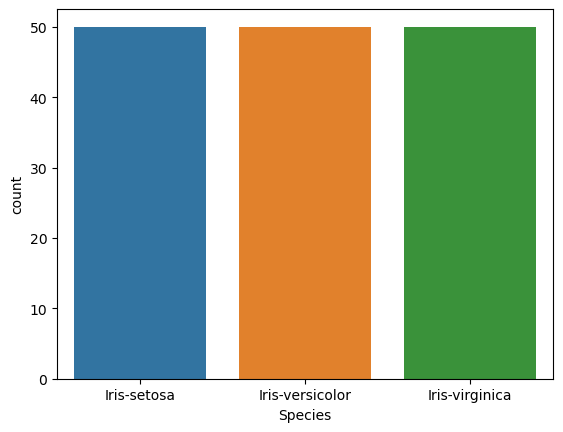

In [22]:
sns.countplot(data=df,x='Species')

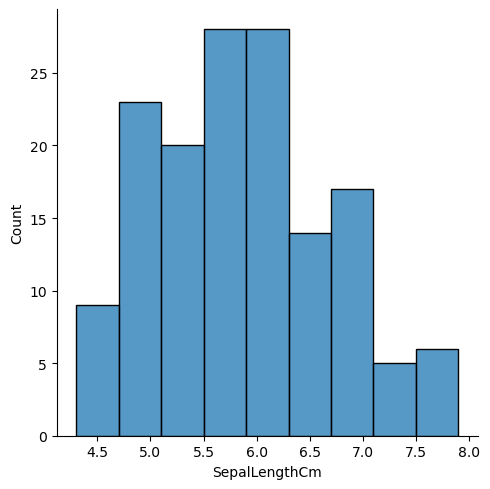

In [23]:
sns.displot(data=df,x='SepalLengthCm')

In [6]:
X=df[['SepalLengthCm','PetalLengthCm','PetalWidthCm','SepalWidthCm']].values

In [7]:
X

array([[5.1, 1.4, 0.2, 3.5],
       [4.9, 1.4, 0.2, 3. ],
       [4.7, 1.3, 0.2, 3.2],
       [4.6, 1.5, 0.2, 3.1],
       [5. , 1.4, 0.2, 3.6],
       [5.4, 1.7, 0.4, 3.9],
       [4.6, 1.4, 0.3, 3.4],
       [5. , 1.5, 0.2, 3.4],
       [4.4, 1.4, 0.2, 2.9],
       [4.9, 1.5, 0.1, 3.1],
       [5.4, 1.5, 0.2, 3.7],
       [4.8, 1.6, 0.2, 3.4],
       [4.8, 1.4, 0.1, 3. ],
       [4.3, 1.1, 0.1, 3. ],
       [5.8, 1.2, 0.2, 4. ],
       [5.7, 1.5, 0.4, 4.4],
       [5.4, 1.3, 0.4, 3.9],
       [5.1, 1.4, 0.3, 3.5],
       [5.7, 1.7, 0.3, 3.8],
       [5.1, 1.5, 0.3, 3.8],
       [5.4, 1.7, 0.2, 3.4],
       [5.1, 1.5, 0.4, 3.7],
       [4.6, 1. , 0.2, 3.6],
       [5.1, 1.7, 0.5, 3.3],
       [4.8, 1.9, 0.2, 3.4],
       [5. , 1.6, 0.2, 3. ],
       [5. , 1.6, 0.4, 3.4],
       [5.2, 1.5, 0.2, 3.5],
       [5.2, 1.4, 0.2, 3.4],
       [4.7, 1.6, 0.2, 3.2],
       [4.8, 1.6, 0.2, 3.1],
       [5.4, 1.5, 0.4, 3.4],
       [5.2, 1.5, 0.1, 4.1],
       [5.5, 1.4, 0.2, 4.2],
       [4.9, 1

In [11]:
kmeans=KMeans(n_clusters=4,random_state=42)

In [12]:
kmeans.fit(X)

KMeans(n_clusters=4, random_state=42)

In [13]:
kmeans.inertia_

57.317873214285726

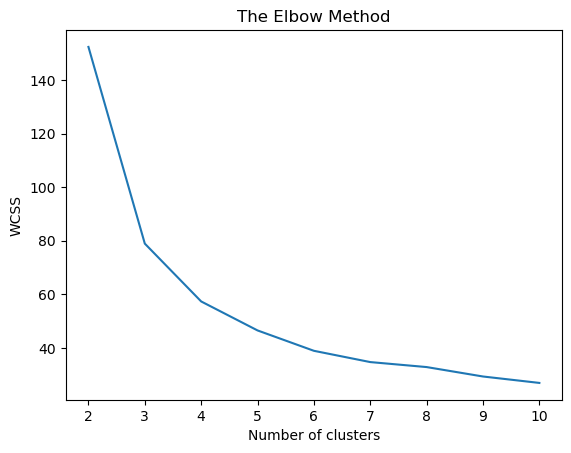

In [14]:
wcss = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters = i, random_state = 42, n_init = 'auto')
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(range(2, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [1]:
kmeans = KMeans(n_clusters = 3, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(X)

NameError: name 'KMeans' is not defined

In [ ]:
kmeans.inertia_

In [17]:
y_kmeans

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0])

In [18]:
X

array([[5.1, 1.4, 0.2, 3.5],
       [4.9, 1.4, 0.2, 3. ],
       [4.7, 1.3, 0.2, 3.2],
       [4.6, 1.5, 0.2, 3.1],
       [5. , 1.4, 0.2, 3.6],
       [5.4, 1.7, 0.4, 3.9],
       [4.6, 1.4, 0.3, 3.4],
       [5. , 1.5, 0.2, 3.4],
       [4.4, 1.4, 0.2, 2.9],
       [4.9, 1.5, 0.1, 3.1],
       [5.4, 1.5, 0.2, 3.7],
       [4.8, 1.6, 0.2, 3.4],
       [4.8, 1.4, 0.1, 3. ],
       [4.3, 1.1, 0.1, 3. ],
       [5.8, 1.2, 0.2, 4. ],
       [5.7, 1.5, 0.4, 4.4],
       [5.4, 1.3, 0.4, 3.9],
       [5.1, 1.4, 0.3, 3.5],
       [5.7, 1.7, 0.3, 3.8],
       [5.1, 1.5, 0.3, 3.8],
       [5.4, 1.7, 0.2, 3.4],
       [5.1, 1.5, 0.4, 3.7],
       [4.6, 1. , 0.2, 3.6],
       [5.1, 1.7, 0.5, 3.3],
       [4.8, 1.9, 0.2, 3.4],
       [5. , 1.6, 0.2, 3. ],
       [5. , 1.6, 0.4, 3.4],
       [5.2, 1.5, 0.2, 3.5],
       [5.2, 1.4, 0.2, 3.4],
       [4.7, 1.6, 0.2, 3.2],
       [4.8, 1.6, 0.2, 3.1],
       [5.4, 1.5, 0.4, 3.4],
       [5.2, 1.5, 0.1, 4.1],
       [5.5, 1.4, 0.2, 4.2],
       [4.9, 1

In [19]:
kmeans.cluster_centers_

array([[5.9016129 , 4.39354839, 1.43387097, 2.7483871 ],
       [5.006     , 1.464     , 0.244     , 3.418     ],
       [6.85      , 5.74210526, 2.07105263, 3.07368421]])

In [20]:
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

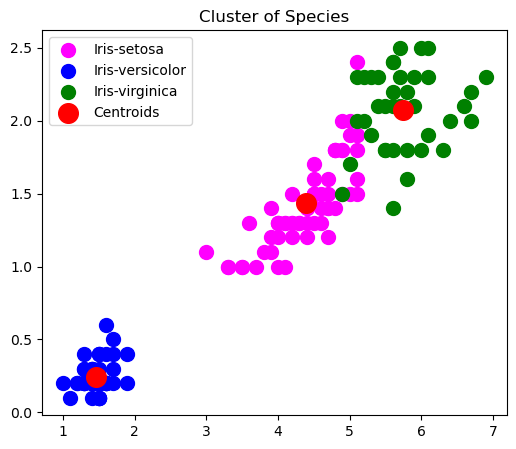

In [32]:
fig = plt.figure(figsize = (6,5))
plt.scatter(X[y_kmeans==0,1],X[y_kmeans==0,2],s=100,c='magenta',label='Iris-setosa')
plt.scatter(X[y_kmeans==1,1],X[y_kmeans==1,2],s=100,c='blue',label='Iris-versicolor')
plt.scatter(X[y_kmeans==2,1],X[y_kmeans==2,2],s=100,c='green',label='Iris-virginica')
plt.scatter(kmeans.cluster_centers_[:,1],kmeans.cluster_centers_[:,2],s=200,c='red',label='Centroids')
plt.title('Cluster of Species')
plt.legend()
plt.show()

In [25]:
silhouette_avg = silhouette_score(X, y_kmeans)
print("The silhouette score is:", silhouette_avg)

The silhouette score is: 0.5525919445499752


In [27]:
kmeans.cluster_centers_

array([[5.9016129 , 4.39354839, 1.43387097, 2.7483871 ],
       [5.006     , 1.464     , 0.244     , 3.418     ],
       [6.85      , 5.74210526, 2.07105263, 3.07368421]])